In [3]:
%pip install pandas

  Using cached pandas-3.0.5-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.2-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.5-cp313-cp313-win_amd64.whl (9.8 MB)
Using cached numpy-2.5.2-cp313-cp313-win_amd64.whl (12.5 MB)
Using cached tzdata-2026.3-py2.py3-none-any.whl (348 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("../data/Mental Distress Dataset-original.csv")

In [6]:
print(df.shape)

(10100, 2)


In [7]:
df.head()

,text,label
0,"I have been (passively at best, actively at wo...",Suicidal
1,Idk when or how but soon. I will likely hang m...,Suicidal
2,I used to say that I would not commit suicide ...,Suicidal
3,Just so I can work minimum wage for 40 years w...,Suicidal
4,"for a little while, i did everything right. i ...",Suicidal


In [8]:
print(df.columns)

Index(['text', 'label'], dtype='str')


In [9]:
print(df.isnull().sum())

text     2
label    0
dtype: int64


In [10]:
print(df["label"].value_counts())

label
Suicidal      2171
Frustrated    2062
Depressed     2051
Anxious       2038
Others        1778
Name: count, dtype: int64


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 29


In [12]:
print("Missing text:", df["text"].isnull().sum())
print("Missing label:", df["label"].isnull().sum())

Missing text: 2
Missing label: 0


In [13]:
print(df["label"].unique())

<StringArray>
['Suicidal', 'Anxious', 'Frustrated', 'Depressed', 'Others']
Length: 5, dtype: str


In [14]:
print(df["text"].str.len().describe())

count    10098.000000
mean       605.066053
std        743.301382
min         12.000000
25%        176.000000
50%        362.000000
75%        754.750000
max      13054.000000
Name: text, dtype: float64


In [15]:
df_clean = df.dropna(subset=["text"]).drop_duplicates()

In [16]:
print(df_clean.shape)

(10069, 2)


In [17]:
print(df_clean.isnull().sum())

text     0
label    0
dtype: int64


In [18]:
print("Duplicates:", df_clean.duplicated().sum())

Duplicates: 0


In [19]:
print(df_clean["label"].value_counts())

label
Suicidal      2170
Depressed     2047
Frustrated    2039
Anxious       2038
Others        1775
Name: count, dtype: int64


In [20]:
df_clean.to_csv("../data/mental_distress_cleaned.csv", index=False)

In [21]:
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [22]:
df_clean.head()

,text,label
0,"I have been (passively at best, actively at wo...",Suicidal
1,Idk when or how but soon. I will likely hang m...,Suicidal
2,I used to say that I would not commit suicide ...,Suicidal
3,Just so I can work minimum wage for 40 years w...,Suicidal
4,"for a little while, i did everything right. i ...",Suicidal


In [23]:
print(df_clean.shape)

(10069, 2)


In [24]:
print(df_clean["text"].iloc[0])

I have been (passively at best, actively at worst) suicidal for more years (14+) than I have not been at this point. It feels like a cancer that I just cannot cut out, no matter what meds I take or what positive life changes I make. When I go to bed at night or take depression naps I cannot help but think of how nice it would be if I died in my sleep. I beg the universe for it sometimes. Especially with the trajectory of the world.And if I am not supposed to die then I wish that life could just pause for a few seconds. I am struggling to breathe, and its maddening not having adequate space to even attempt to work through these awful feelings. How do I tell my job, friends, family that my daily performance is suffering because I wish I was dead? How do I provide for myself if I am in long-term treatment? Rent does not go away. Responsibilities will pile up. I am so worried that if I acknowledge how bad things are and try to seek help that my life would only get worse and that it would b

In [25]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

In [27]:
df_clean["clean_text"] = df_clean["text"].apply(clean_text)

In [28]:
df_clean[["text", "clean_text"]].head()

,text,clean_text
0,"I have been (passively at best, actively at wo...","i have been (passively at best, actively at wo..."
1,Idk when or how but soon. I will likely hang m...,idk when or how but soon. i will likely hang m...
2,I used to say that I would not commit suicide ...,i used to say that i would not commit suicide ...
3,Just so I can work minimum wage for 40 years w...,just so i can work minimum wage for 40 years w...
4,"for a little while, i did everything right. i ...","for a little while, i did everything right. i ..."


In [30]:
%pip install scikit-learn

  Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.18.0-cp313-cp313-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
Using cached scipy-1.18.0-cp313-cp313-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
from sklearn.model_selection import train_test_split

In [32]:
X = df_clean["clean_text"]
y = df_clean["label"]

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [34]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8055
Testing samples: 2014


In [35]:
print(y_train.value_counts())
print(y_test.value_counts())

label
Suicidal      1736
Depressed     1638
Frustrated    1631
Anxious       1630
Others        1420
Name: count, dtype: int64
label
Suicidal      434
Depressed     409
Anxious       408
Frustrated    408
Others        355
Name: count, dtype: int64


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [37]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2)
)

In [38]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [39]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (8055, 10000)
Testing TF-IDF shape: (2014, 10000)


model 1

In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [42]:
lr_model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [43]:
y_pred_lr = lr_model.predict(X_test_tfidf)

In [44]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

Logistic Regression Accuracy: 0.7730883813306852


In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

     Anxious       0.94      0.92      0.93       408
   Depressed       0.62      0.55      0.58       409
  Frustrated       0.85      0.84      0.85       408
      Others       0.70      0.82      0.76       355
    Suicidal       0.74      0.75      0.74       434

    accuracy                           0.77      2014
   macro avg       0.77      0.77      0.77      2014
weighted avg       0.77      0.77      0.77      2014



model 2

In [46]:
from sklearn.naive_bayes import MultinomialNB

In [47]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

In [48]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)

Naive Bayes Accuracy: 0.7254220456802384


In [49]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

     Anxious       0.84      0.92      0.88       408
   Depressed       0.66      0.48      0.56       409
  Frustrated       0.73      0.82      0.77       408
      Others       0.80      0.48      0.60       355
    Suicidal       0.64      0.88      0.74       434

    accuracy                           0.73      2014
   macro avg       0.73      0.72      0.71      2014
weighted avg       0.73      0.73      0.71      2014



model 3

In [50]:
from sklearn.svm import LinearSVC

In [51]:
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

In [52]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Linear SVM Accuracy:", accuracy_svm)

Linear SVM Accuracy: 0.7671300893743793


In [53]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

     Anxious       0.93      0.93      0.93       408
   Depressed       0.61      0.58      0.59       409
  Frustrated       0.85      0.82      0.83       408
      Others       0.73      0.80      0.76       355
    Suicidal       0.71      0.72      0.71       434

    accuracy                           0.77      2014
   macro avg       0.77      0.77      0.77      2014
weighted avg       0.77      0.77      0.77      2014



confusion matrix

In [55]:
%pip install matplotlib

  Using cached matplotlib-3.11.1-cp313-cp313-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp313-cp313-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
Using cached pillow-12.3.0-cp313-cp313-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
Note: you may need to restart the kernel to use updated packages.


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


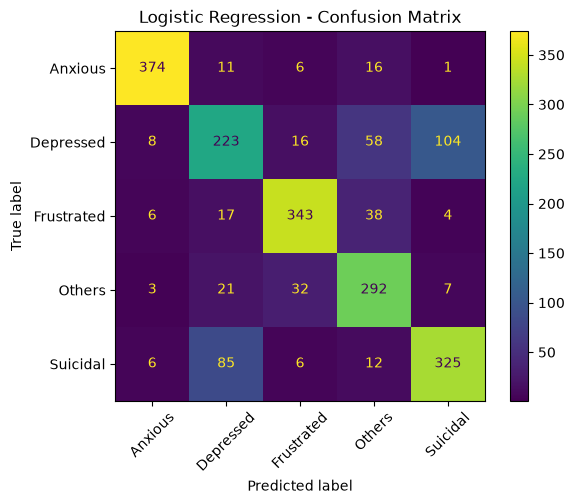

In [57]:
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lr_model.classes_
)

disp.plot(xticks_rotation=45)
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

save

In [58]:
%pip install joblib


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



Note: you may need to restart the kernel to use updated packages.


In [59]:
import joblib

In [60]:
joblib.dump(lr_model, "../models/mental_health_model.pkl")

['../models/mental_health_model.pkl']

In [61]:
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']

In [62]:
import os

print(os.path.exists("../models/mental_health_model.pkl"))
print(os.path.exists("../models/tfidf_vectorizer.pkl"))

True
True


In [63]:
test_text = ["I feel worried and nervous about everything."]

In [64]:
test_vector = tfidf.transform(test_text)
prediction = lr_model.predict(test_vector)

print("Predicted label:", prediction[0])

Predicted label: Anxious


In [65]:
test_text = ["I am feeling very frustrated with my life."]
test_vector = tfidf.transform(test_text)
prediction = lr_model.predict(test_vector)

print("Predicted label:", prediction[0])

Predicted label: Depressed
